In [16]:
# Roll No: 24BAD067

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [17]:
print("manoj m")
df = pd.read_csv("/Users/manojmj/PycharmProjects/machinelearning subject/expno4/data/spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()


manoj m


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
print("Manoj M 24BAD067")
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['message'] = df['message'].apply(clean_text)


Manoj M 24BAD067


In [19]:
print("Manoj M 24BAD067")
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])  # ham=0, spam=1


Manoj M 24BAD067


In [20]:
print("Manoj M 24BAD067")
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['message'])


Manoj M 24BAD067


In [21]:
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['message'])


In [22]:
print("Manoj M 24BAD067")
y = df['label']


Manoj M 24BAD067


In [23]:
print("Manoj M 24BAD067")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Manoj M 24BAD067


In [24]:
print("Manoj M 24BAD067")
model = MultinomialNB(alpha=1.0)  # Laplace smoothing
model.fit(X_train, y_train)


Manoj M 24BAD067


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [25]:
print("Manoj M 24BAD067")
y_pred = model.predict(X_test)


Manoj M 24BAD067


In [26]:
print("Manoj M 24BAD067")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Manoj M 24BAD067
Accuracy: 0.968609865470852
Precision: 1.0
Recall: 0.7666666666666667
F1 Score: 0.8679245283018868


In [27]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



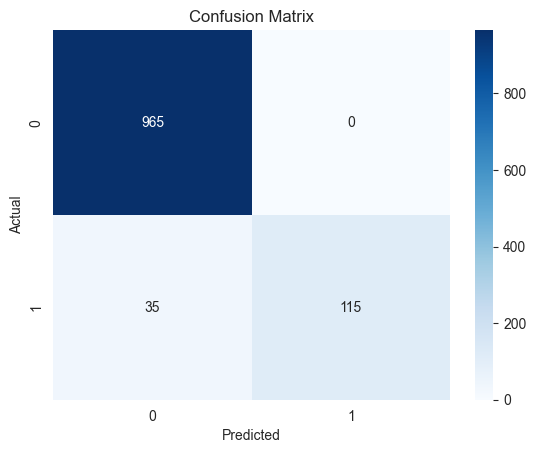

In [28]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [29]:
misclassified = df.iloc[y_test.index][y_test != y_pred]
misclassified.head()


,label,message
1044,1,we know someone who you know that fancies you ...
683,1,hi im sue i am years old and work as a lapdan...
4071,1,loans for any purpose even if you have bad cre...
2312,1,tddnewsletteremccouk more games from thedailyd...
3979,1,ringtoneking


In [30]:
model = MultinomialNB(alpha=0.1)


In [31]:
print(hasattr(model, "feature_log_prob_"))

False


In [32]:
model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [33]:
print(hasattr(model, "feature_log_prob_"))

True


In [34]:
feature_names = vectorizer.get_feature_names_out()

spam_log_probs = model.feature_log_prob_[1]

top_spam_indices = np.argsort(spam_log_probs)[-20:]

print("Top words influencing SPAM classification:\n")

for i in top_spam_indices:
    print(feature_names[i])

Top words influencing SPAM classification:

just
ppm
guaranteed
contact
win
service
nokia
cash
new
urgent
reply
won
text
ur
stop
prize
mobile
claim
txt
free


In [35]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['message'])

model.fit(X_train, y_train)

# Later
vectorizer = CountVectorizer()   # <-- overwritten


In [36]:
print("Manoj M 24BAD067")
def show_top_words(model, vectorizer, n=20):
    feature_names = vectorizer.get_feature_names_out()

    for class_index, class_label in enumerate(["Ham", "Spam"]):
        top_indices = np.argsort(model.feature_log_prob_[class_index])[-n:]
        print(f"\nTop {n} words for {class_label}:")
        for i in top_indices:
            print(feature_names[i])

Manoj M 24BAD067


In [37]:
print("Manoj M 24BAD067")
spam_words = df[df['label']==1]['message']
ham_words = df[df['label']==0]['message']

spam_vector = CountVectorizer(stop_words='english').fit_transform(spam_words)
ham_vector = CountVectorizer(stop_words='english').fit_transform(ham_words)

print("Top spam words:", spam_vector.sum(axis=0))

Manoj M 24BAD067
Top spam words: [[1 1 1 ... 1 1 1]]
